# Wildfire Spread: From Physical Simulation to Suppression Strategy

> *A wildfire is a stochastic system. Suppression is a decision problem under uncertainty.*

This notebook models wildfire as two interlocking problems:

**Layer 1: Physical simulation:** A cellular automaton where fire spreads
based on fuel type, terrain slope, moisture, and wind. The same physics
that underlie FARSITE (Fire Area Simulator) used by the US Forest Service.

**Layer 2: Strategic game:** A player allocates limited suppression resources
each timestep (firebreaks, retardant drops, crew deployment) to minimize
burned area. Monte Carlo analysis then asks: which strategy works best,
and under what conditions?

The bridge between these layers is the core concept of this notebook:
**expected value under uncertainty**. Every suppression action has an EV
that depends on fire spread probability, wind direction, and what burns
if you do nothing. This is the same analytical structure as environmental
risk modeling, emergency management, and public health response allocation.

In [1]:
# Imports
import sys, math, time
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib.collections import PatchCollection

import terrain    as tr
import simulation as sim
import game       as gm
import analyzer   as az

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "#0d1b2a",
    "axes.facecolor":   "#0d1b2a",
    "text.color":       "#dde8f0",
    "axes.edgecolor":   "#2a4a6a",
    "axes.labelcolor":  "#dde8f0",
    "xtick.color":      "#dde8f0",
    "ytick.color":      "#dde8f0",
    "grid.color":       "#1e3040",
    "grid.alpha":       0.4,
})
# print("terrain.py   :", tr.__file__)
# print("simulation.py:", sim.__file__)
# print("game.py      :", gm.__file__)
# print("analyzer.py  :", az.__file__)
print("Imports complete.")

Imports complete.


## The Landscape

Before fire can spread, we need terrain. The landscape is a 40×40 grid
(each cell = 1 hectare). Fuel type, elevation, and moisture are generated
from a seeded random process that produces realistic ridge-and-valley terrain.

Fuel types follow simplified NFDRS fuel model classifications:
- **Grass**: fastest spread, low intensity, low value
- **Shrub**: moderate spread and intensity
- **Forest**: slowest spread, highest intensity, highest value
- **Roads and water**: natural and artificial firebreaks

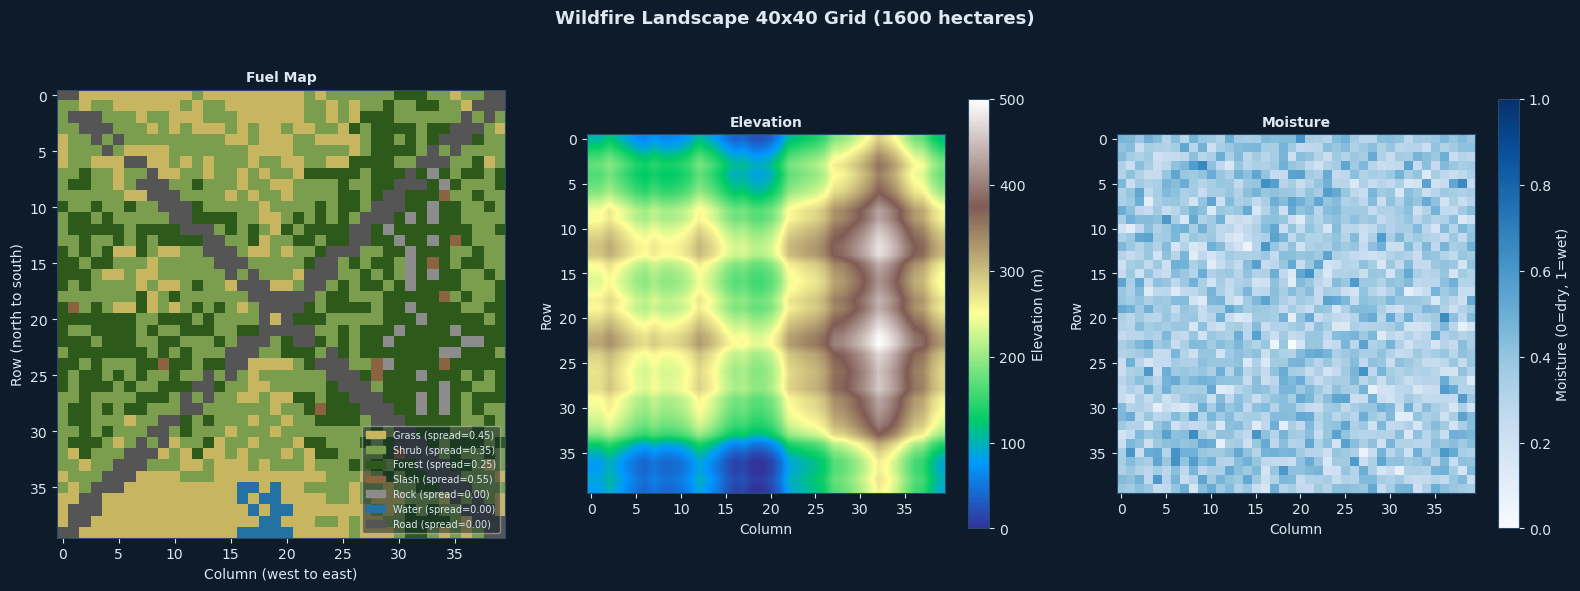

Grid: 40 x 40 = 1600 cells (1600 hectares)
Burnable cells: 1362
Natural firebreaks (road/water/rock): 238


In [12]:
# Build the landscape and visualize it
SEED = 42
terrain = tr.Terrain(rows=40, cols=40, seed=SEED,
                     moisture_mean=0.30, moisture_std=0.10)

FUEL_COLORS = {f: props.color for f, props in tr.FUEL_PROPS.items()}

def plot_terrain(terrain, title="Terrain", ax=None, show_elev=False):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 8))
    rgb = terrain.rgb_array()
    ax.imshow(rgb, origin="upper", interpolation="nearest")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Column (west to east)")
    ax.set_ylabel("Row (north to south)")
    if standalone:
        plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Left: fuel map
plot_terrain(terrain, "Fuel Map", ax=axes[0])
legend_el = [mpatches.Patch(color=props.color,
             label=f"{ft.value.title()} (spread={props.base_spread_rate:.2f})")
             for ft, props in tr.FUEL_PROPS.items()
             if ft != tr.FuelType.BURNED]
axes[0].legend(handles=legend_el, fontsize=7, loc="lower right",
               framealpha=0.5, ncol=1)

# Middle: elevation
im_elev = axes[1].imshow(terrain.elevation, cmap="terrain",
                          origin="upper", interpolation="bilinear")
plt.colorbar(im_elev, ax=axes[1], label="Elevation (m)", shrink=0.8)
axes[1].set_title("Elevation", fontsize=10, fontweight="bold")
axes[1].set_xlabel("Column"); axes[1].set_ylabel("Row")

# Right: moisture
im_moist = axes[2].imshow(terrain.moisture, cmap="Blues",
                           origin="upper", vmin=0, vmax=1)
plt.colorbar(im_moist, ax=axes[2], label="Moisture (0=dry, 1=wet)", shrink=0.8)
axes[2].set_title("Moisture", fontsize=10, fontweight="bold")
axes[2].set_xlabel("Column"); axes[2].set_ylabel("Row")

plt.suptitle("Wildfire Landscape 40x40 Grid (1600 hectares)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

total_burnable = sum(
    1 for r in range(terrain.rows) for c in range(terrain.cols)
    if terrain.cells[r][c].is_burnable
)
print(f"Grid: {terrain.rows} x {terrain.cols} = {terrain.rows*terrain.cols} cells "
      f"({terrain.rows*terrain.cols} hectares)")
print(f"Burnable cells: {total_burnable}")
print(f"Natural firebreaks (road/water/rock): {terrain.rows*terrain.cols - total_burnable}")

## A Single Fire Run

Wind blows from the south at 5 m/s. Ignition starts at the center-left.
Watch fire spread northeast, channeled by terrain and fuel corridors.

Fire simulation complete
  Timesteps    : 80
  Cells burned : 887 / 1600
  Value burned : 1669.5
  Value saved  : 860.5
  % area burned: 55.4%


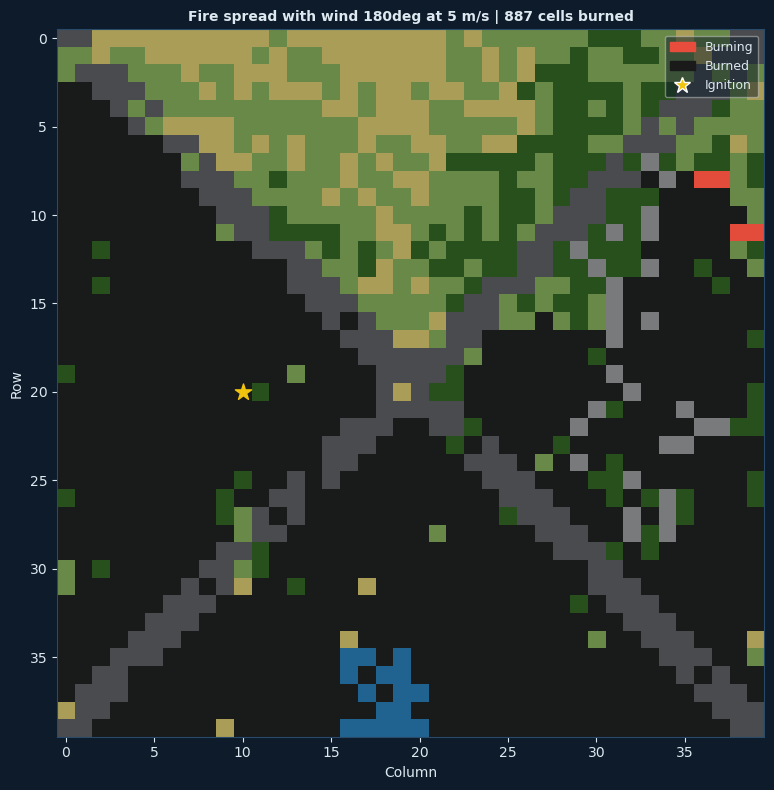

In [3]:
def plot_fire_state(terrain, result, title="Fire Spread", ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 8))

    rgb = terrain.rgb_array()
    ax.imshow(rgb, origin="upper", interpolation="nearest", alpha=0.85)

    FIRE_OVERLAY = {
        tr.FireState.BURNING:    (231/255, 76/255,  60/255,  0.9),
        tr.FireState.BURNED:     (26/255,  26/255,  26/255,  0.85),
        tr.FireState.SUPPRESSED: (0/255,  188/255, 212/255,  0.9),
    }
    overlay = np.zeros((terrain.rows, terrain.cols, 4))
    for r in range(terrain.rows):
        for c in range(terrain.cols):
            state = terrain.cells[r][c].fire_state
            if state in FIRE_OVERLAY:
                overlay[r, c] = FIRE_OVERLAY[state]
    ax.imshow(overlay, origin="upper", interpolation="nearest")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Column"); ax.set_ylabel("Row")
    if standalone:
        plt.tight_layout(); plt.show()

# Run a single fire
IGNITION = (20, 10)
wind     = tr.Wind(direction_deg=180.0, speed_ms=5.0)
terrain  = tr.Terrain(40, 40, seed=SEED)
rng      = np.random.default_rng(SEED + 1)
result   = sim.run_simulation(terrain, IGNITION, wind, rng=rng)

print(f"Fire simulation complete")
print(f"  Timesteps    : {result.timesteps}")
print(f"  Cells burned : {result.cells_burned} / {terrain.rows*terrain.cols}")
print(f"  Value burned : {result.value_burned:.1f}")
print(f"  Value saved  : {result.value_saved:.1f}")
print(f"  % area burned: {result.cells_burned/(terrain.rows*terrain.cols)*100:.1f}%")

fig, ax = plt.subplots(figsize=(9, 8))
plot_fire_state(terrain, result,
    f"Fire spread with wind 180deg at 5 m/s | {result.cells_burned} cells burned",
    ax=ax)
ax.scatter([IGNITION[1]], [IGNITION[0]], color="#f1c40f", s=150,
           marker="*", zorder=5, label="Ignition point")
ax.legend(fontsize=9)

legend_fire = [
    mpatches.Patch(color="#e74c3c", label="Burning"),
    mpatches.Patch(color="#1a1a1a", label="Burned"),
]
ax.legend(handles=legend_fire + [
    plt.Line2D([0],[0], marker="*", color="w", markerfacecolor="#f1c40f",
               markersize=12, linestyle="", label="Ignition")
], fontsize=9, loc="upper right", framealpha=0.5)

plt.tight_layout(); plt.show()

### Fire spread sensitivity: slope, wind, and moisture

The spread formula has three physical parameters. Let's see how each
one changes the fire's behavior.

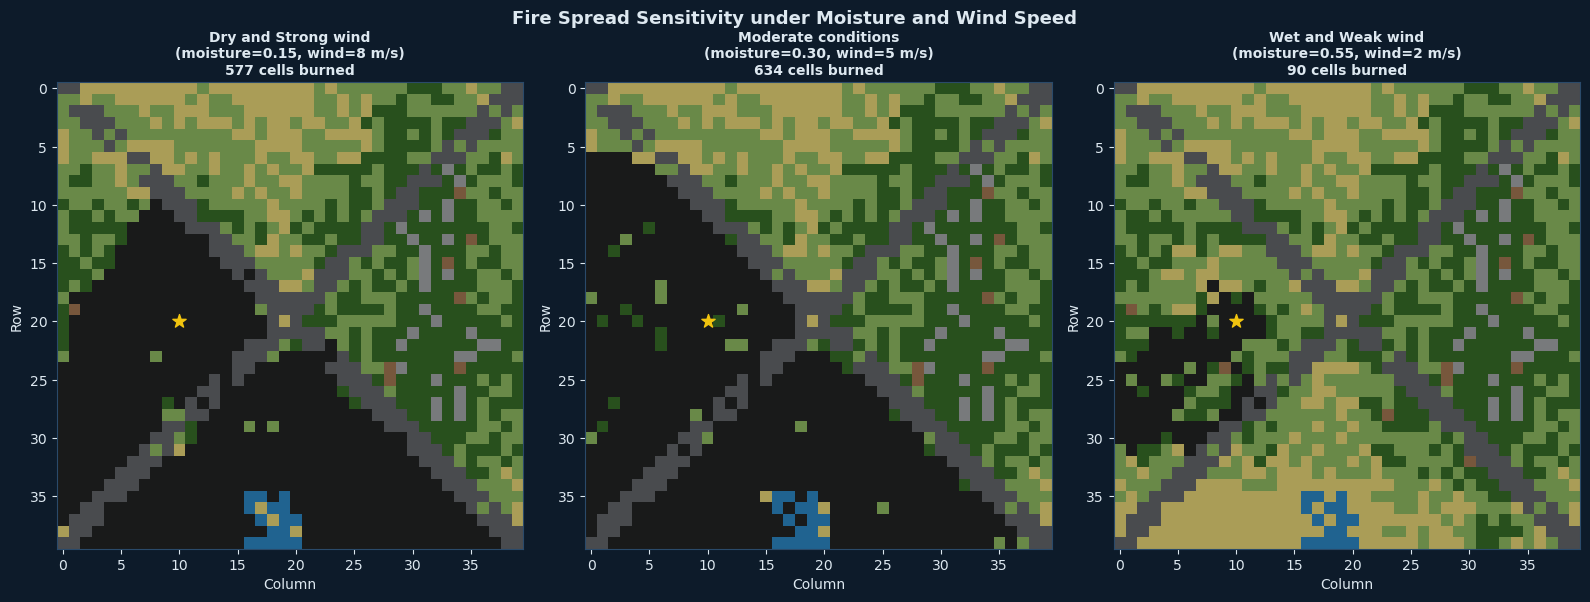

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

scenarios = [
    ("Dry and Strong wind\n(moisture=0.15, wind=8 m/s)",
     {"moisture_mean":0.15, "wind_speed":8.0, "wind_direction":180.0}),
    ("Moderate conditions\n(moisture=0.30, wind=5 m/s)",
     {"moisture_mean":0.30, "wind_speed":5.0, "wind_direction":180.0}),
    ("Wet and Weak wind\n(moisture=0.55, wind=2 m/s)",
     {"moisture_mean":0.55, "wind_speed":2.0, "wind_direction":180.0}),
]

for ax, (title, params) in zip(axes, scenarios):
    t2 = tr.Terrain(40, 40, seed=SEED,
                    moisture_mean=params["moisture_mean"], moisture_std=0.08)
    w2 = tr.Wind(direction_deg=params["wind_direction"],
                 speed_ms=params["wind_speed"])
    r2 = sim.run_simulation(t2, IGNITION, w2,
                            rng=np.random.default_rng(SEED+1))
    plot_fire_state(t2, r2,
        f"{title}\n{r2.cells_burned} cells burned", ax=ax)
    ax.scatter([IGNITION[1]], [IGNITION[0]], color="#f1c40f",
               s=100, marker="*", zorder=5)

plt.suptitle("Fire Spread Sensitivity under Moisture and Wind Speed",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## Stochastic Analysis: The Fire Perimeter Distribution

A single simulation run is a point estimate. Real fire management requires
understanding the *distribution* of outcomes or how variable is fire spread
under realistic uncertainty in wind and moisture?

We run 150 Monte Carlo simulations with wind direction drawn from a
normal distribution (mean 180°, std 20°) and moisture varying similarly.
The result shows the range of possible fire perimeters. Where is the
median perimeter, and what does the 90th percentile look like?

In [5]:
print("Running 150 Monte Carlo fire simulations...")
rng_mc = np.random.default_rng(99)

# Sample environmental conditions
n_mc = 150
wind_dirs   = rng_mc.normal(180, 20, n_mc)
wind_speeds = np.clip(rng_mc.normal(5.0, 2.0, n_mc), 0.5, 12.0)
moistures   = np.clip(rng_mc.normal(0.30, 0.08, n_mc), 0.05, 0.80)

mc_results = []
for i in range(n_mc):
    t_mc = tr.Terrain(40, 40, seed=SEED,
                      moisture_mean=float(moistures[i]), moisture_std=0.06)
    w_mc = tr.Wind(direction_deg=float(wind_dirs[i]),
                   speed_ms=float(wind_speeds[i]))
    r_mc = sim.run_simulation(t_mc, IGNITION, w_mc,
                              rng=np.random.default_rng(i + 1000))
    mc_results.append({
        "wind_dir":    wind_dirs[i],
        "wind_speed":  wind_speeds[i],
        "moisture":    moistures[i],
        "cells_burned":r_mc.cells_burned,
        "value_burned":r_mc.value_burned,
        "timesteps":   r_mc.timesteps,
    })

mc_df = pd.DataFrame(mc_results)
print(f"Complete. Statistics across {n_mc} runs:")
print(mc_df[["cells_burned","value_burned","timesteps"]].describe().round(2).to_string())

Running 150 Monte Carlo fire simulations...
Complete. Statistics across 150 runs:
       cells_burned  value_burned  timesteps
count        150.00        150.00     150.00
mean         562.11        999.50      53.13
std          284.37        497.10      18.29
min            1.00          3.00       3.00
25%          323.25        633.00      43.00
50%          580.00        993.00      50.00
75%          658.75       1154.75      69.75
max         1304.00       2411.00      80.00


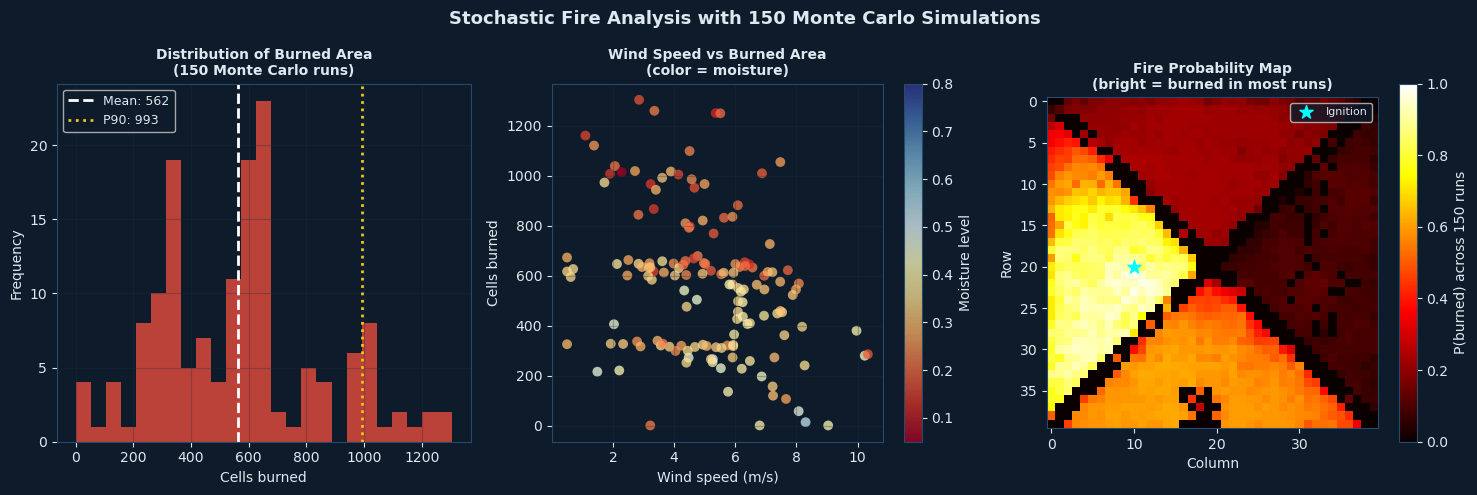

Cells at P(burn) > 0.9: 65 (core burn zone)
Cells at P(burn) > 0.5: 603 (likely burn zone)
Cells at P(burn) > 0.1: 1111 (possible burn zone)


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Left: distribution of cells burned
ax = axes[0]
ax.hist(mc_df["cells_burned"], bins=25, color="#e74c3c", alpha=0.8, edgecolor="none")
ax.axvline(mc_df["cells_burned"].mean(), color="white", linewidth=2,
           linestyle="--", label=f"Mean: {mc_df['cells_burned'].mean():.0f}")
ax.axvline(mc_df["cells_burned"].quantile(0.9), color="#f1c40f", linewidth=2,
           linestyle=":", label=f"P90: {mc_df['cells_burned'].quantile(0.9):.0f}")
ax.set_xlabel("Cells burned")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Burned Area\n(150 Monte Carlo runs)",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Middle: wind speed vs burned area
ax = axes[1]
sc = ax.scatter(mc_df["wind_speed"], mc_df["cells_burned"],
                c=mc_df["moisture"], cmap="RdYlBu", vmin=0.05, vmax=0.8,
                s=50, alpha=0.75, edgecolors="none")
plt.colorbar(sc, ax=ax, label="Moisture level")
ax.set_xlabel("Wind speed (m/s)")
ax.set_ylabel("Cells burned")
ax.set_title("Wind Speed vs Burned Area\n(color = moisture)",
             fontsize=10, fontweight="bold")
ax.grid(alpha=0.3)

# Right: fire perimeter heatmap
# Count how many runs burned each cell
burn_count = np.zeros((40, 40))
for i in range(n_mc):
    t_mc = tr.Terrain(40, 40, seed=SEED,
                      moisture_mean=float(moistures[i]), moisture_std=0.06)
    w_mc = tr.Wind(direction_deg=float(wind_dirs[i]),
                   speed_ms=float(wind_speeds[i]))
    r_mc = sim.run_simulation(t_mc, IGNITION, w_mc,
                              rng=np.random.default_rng(i + 1000))
    for ts, r, c in r_mc.burn_sequence:
        burn_count[r, c] += 1

burn_prob = burn_count / n_mc
ax = axes[2]
im = ax.imshow(burn_prob, cmap="hot", origin="upper", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="P(burned) across 150 runs")
ax.scatter([IGNITION[1]], [IGNITION[0]], color="cyan", s=100,
           marker="*", zorder=5, label="Ignition")
ax.set_title("Fire Probability Map\n(bright = burned in most runs)",
             fontsize=10, fontweight="bold")
ax.set_xlabel("Column"); ax.set_ylabel("Row")
ax.legend(fontsize=8)

plt.suptitle("Stochastic Fire Analysis with 150 Monte Carlo Simulations",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"Cells at P(burn) > 0.9: {(burn_prob > 0.9).sum()} (core burn zone)")
print(f"Cells at P(burn) > 0.5: {(burn_prob > 0.5).sum()} (likely burn zone)")
print(f"Cells at P(burn) > 0.1: {(burn_prob > 0.1).sum()} (possible burn zone)")

## Suppression as a Decision Problem

Now we introduce the game layer. A player has 4 suppression points per turn.
Three actions are available:

| Action | Cost | Effect | When best |
|---|---|---|---|
| Firebreak | 2 pts | Remove fuel permanently | Proactive before fire arrives |
| Retardant drop | 3 pts | Reduce spread 70% in 3×3 for 3 turns | Slowing flanks |
| Crew deploy | 1 pt | Extinguish one burning cell | Reactive after ignition |

**Expected value of suppression** the crucial analytical quantity:
- Firebreak EV = P(fire reaches cell) × cell value × downstream value protected
- Crew EV = neighbor risk from this burning cell
- Retardant EV = sum of firebreak EVs in 3×3 area × 0.4

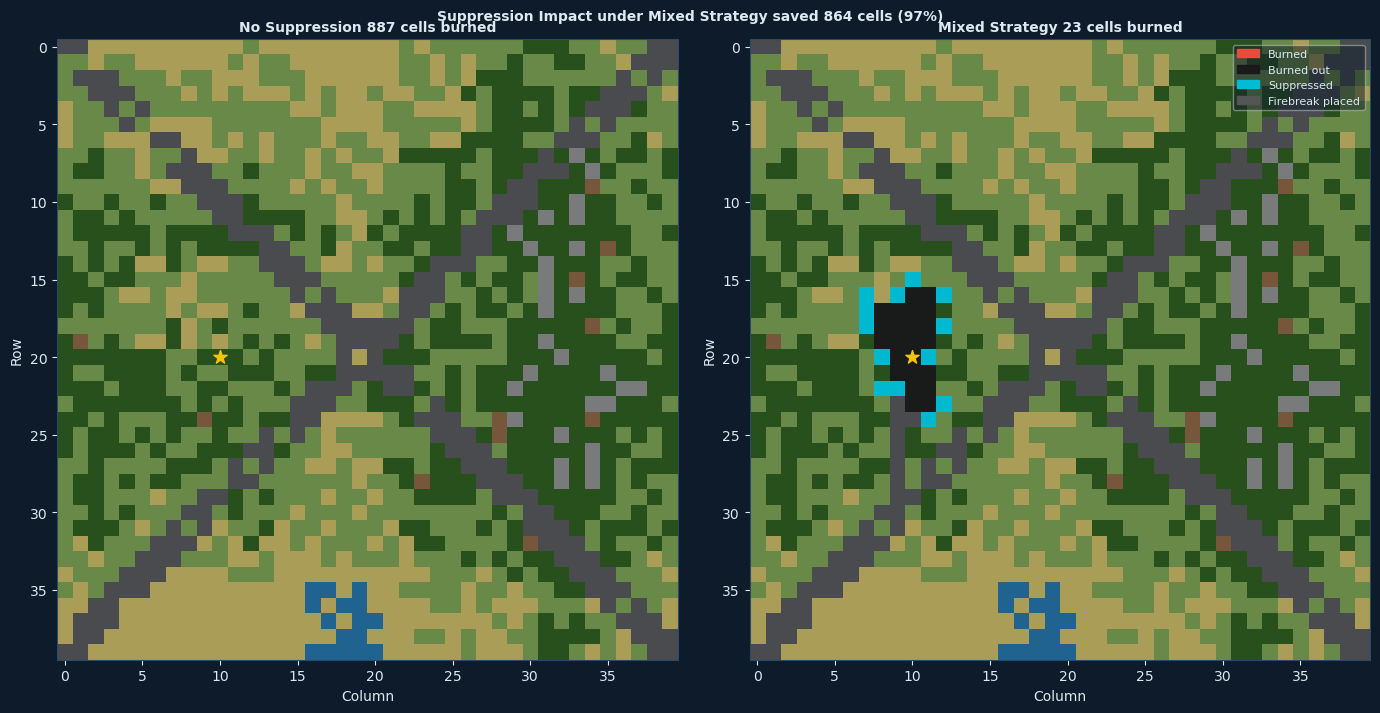

In [15]:
# Show a single suppression run under Mixed strategy
terrain_s = tr.Terrain(40, 40, seed=SEED)
wind_s    = tr.Wind(direction_deg=180.0, speed_ms=5.0)
rng_s     = np.random.default_rng(SEED + 50)

result_nosup = sim.run_simulation(
    tr.Terrain(40, 40, seed=SEED), IGNITION, wind_s,
    rng=np.random.default_rng(SEED+1))

result_mixed = gm.run_with_suppression(
    terrain_seed=SEED, ignition_pt=IGNITION,
    wind=wind_s, strategy_fn=gm.STRATEGIES["Mixed"],
    budget_per_turn=4, suppression_start=3,
    rng=rng_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
plot_fire_state(
    tr.Terrain(40, 40, seed=SEED),
    result_nosup,
    f"No Suppression {result_nosup.cells_burned} cells burned",
    ax=axes[0])
axes[0].scatter([IGNITION[1]], [IGNITION[0]], color="#f1c40f",
                s=100, marker="*", zorder=5)

plot_fire_state(
    result_mixed.terrain, result_mixed,
    f"Mixed Strategy {result_mixed.cells_burned} cells burned",
    ax=axes[1])
axes[1].scatter([IGNITION[1]], [IGNITION[0]], color="#f1c40f",
                s=100, marker="*", zorder=5)

legend_el = [
    mpatches.Patch(color="#e74c3c", label="Burned"),
    mpatches.Patch(color="#1a1a1a", label="Burned out"),
    mpatches.Patch(color="#00bcd4", label="Suppressed"),
    mpatches.Patch(color="#555555", label="Firebreak placed"),
]
axes[1].legend(handles=legend_el, fontsize=8, loc="upper right", framealpha=0.5)

savings = result_nosup.cells_burned - result_mixed.cells_burned
plt.suptitle(f"Suppression Impact under Mixed Strategy saved {savings} cells "
             f"({savings/(result_nosup.cells_burned+1e-9)*100:.0f}%)",
             fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

## Monte Carlo Strategy Comparison

The single-run comparison shows one scenario. We need to compare strategies
across many scenarios to understand:
- Which strategy saves the most cells on average?
- Which strategy has the lowest variance (most reliable)?
- Under which conditions does each strategy dominate?

In [8]:
cfg = az.MonteCarloConfig(
    n_runs=200, seed=7,
    wind_dir_mean=180, wind_dir_std=20,
    wind_speed_mean=5.0, wind_speed_std=2.0,
    moisture_mean=0.30, moisture_std=0.08,
    budget_per_turn=4, suppression_start=3,
    ignition_row=20, ignition_col=10,
)

print("Running Monte Carlo strategy comparison (200 runs x 3 strategies)...")
print("This takes ~2 minutes.")
t0 = time.perf_counter()

df_strategies = az.run_monte_carlo(cfg)
df_baseline   = az.run_baseline(cfg)
df_all        = pd.concat([df_strategies, df_baseline], ignore_index=True)

elapsed = time.perf_counter() - t0
print(f"Complete in {elapsed:.0f}s")
print()
print(az.summarize(df_all).to_string(index=False))

Running Monte Carlo strategy comparison (200 runs x 3 strategies)...
This takes ~2 minutes.
  Running Reactive (200 runs)...
  Running Proactive (200 runs)...
  Running Mixed (200 runs)...
  Running Baseline/No suppression (200 runs)...
Complete in 18s

      strategy  mean_burned  std_burned  p10_burned  p50_burned  p90_burned  mean_saved  std_saved  cv_burned
         Mixed        10.60       15.23         1.0         4.0        33.3     2528.59     179.79       1.44
No suppression       427.20      275.44       129.4       337.0       792.6     1790.84     537.15       0.64
     Proactive       340.29      232.32        55.0       284.0       619.5     1873.55     488.32       0.68
      Reactive         2.50        2.53         1.0         2.0         5.1     2552.69     172.49       1.01


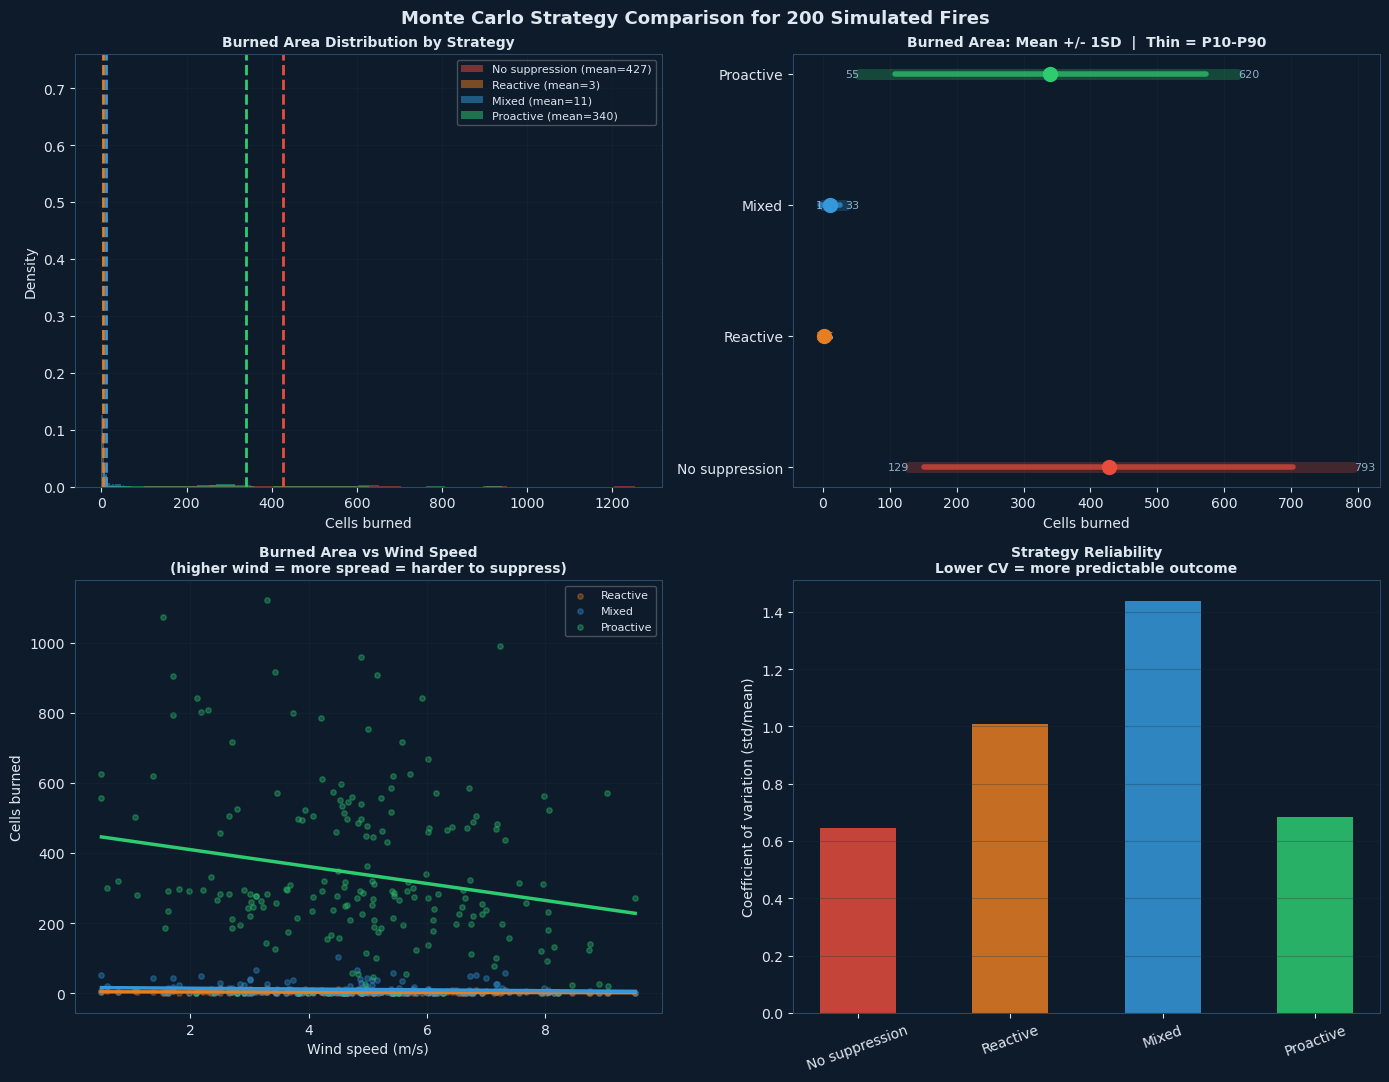

In [9]:
STRATEGY_COLORS = {
    "No suppression": "#e74c3c",
    "Reactive":       "#e67e22",
    "Mixed":          "#3498db",
    "Proactive":      "#2ecc71",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Top left: distribution of cells burned per strategy
ax = axes[0][0]
for strat in ["No suppression","Reactive","Mixed","Proactive"]:
    sub = df_all[df_all["strategy"] == strat]["cells_burned"]
    ax.hist(sub, bins=25, alpha=0.5, color=STRATEGY_COLORS[strat],
            label=f"{strat} (mean={sub.mean():.0f})", density=True)
    ax.axvline(sub.mean(), color=STRATEGY_COLORS[strat], linewidth=2, linestyle="--")
ax.set_xlabel("Cells burned")
ax.set_ylabel("Density")
ax.set_title("Burned Area Distribution by Strategy",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=8, framealpha=0.3); ax.grid(alpha=0.3)

# Top right: mean +/- std swim lanes
ax = axes[0][1]
summary = az.summarize(df_all)
strategy_order = ["No suppression","Reactive","Mixed","Proactive"]
y = range(len(strategy_order))
for i, strat in enumerate(strategy_order):
    row = summary[summary["strategy"] == strat].iloc[0]
    color = STRATEGY_COLORS[strat]
    ax.plot([row.p10_burned, row.p90_burned], [i, i],
            color=color, linewidth=8, alpha=0.25, solid_capstyle="round")
    ax.plot([row.mean_burned - row.std_burned,
             row.mean_burned + row.std_burned], [i, i],
            color=color, linewidth=4, alpha=0.7, solid_capstyle="round")
    ax.scatter([row.mean_burned], [i], color=color, s=100, zorder=5)
    ax.text(row.p10_burned - 0.5, i, f"{row.p10_burned:.0f}",
            va="center", ha="right", fontsize=8, color="#90b0c8")
    ax.text(row.p90_burned + 0.5, i, f"{row.p90_burned:.0f}",
            va="center", ha="left", fontsize=8, color="#90b0c8")

ax.set_yticks(range(len(strategy_order)))
ax.set_yticklabels(strategy_order)
ax.set_xlabel("Cells burned")
ax.set_title("Burned Area: Mean +/- 1SD  |  Thin = P10-P90",
             fontsize=10, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

# Bottom left: cells burned vs wind speed by strategy
ax = axes[1][0]
for strat in ["Reactive","Mixed","Proactive"]:
    sub = df_all[df_all["strategy"] == strat]
    ax.scatter(sub["wind_speed"], sub["cells_burned"],
               color=STRATEGY_COLORS[strat], s=15, alpha=0.35, label=strat)
    # Trend line
    m, b = np.polyfit(sub["wind_speed"], sub["cells_burned"], 1)
    xs = np.linspace(sub["wind_speed"].min(), sub["wind_speed"].max(), 50)
    ax.plot(xs, m*xs+b, color=STRATEGY_COLORS[strat], linewidth=2.5)

ax.set_xlabel("Wind speed (m/s)")
ax.set_ylabel("Cells burned")
ax.set_title("Burned Area vs Wind Speed\n(higher wind = more spread = harder to suppress)",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=8, framealpha=0.3); ax.grid(alpha=0.3)

# Bottom right: coefficient of variation (variance/mean)
ax = axes[1][1]
strategies = ["No suppression","Reactive","Mixed","Proactive"]
cvs = []
for strat in strategies:
    sub = df_all[df_all["strategy"] == strat]["cells_burned"]
    cvs.append(sub.std() / sub.mean())
colors = [STRATEGY_COLORS[s] for s in strategies]
ax.bar(strategies, cvs, color=colors, alpha=0.85, width=0.5)
ax.set_ylabel("Coefficient of variation (std/mean)")
ax.set_title("Strategy Reliability\nLower CV = more predictable outcome",
             fontsize=10, fontweight="bold")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Monte Carlo Strategy Comparison for 200 Simulated Fires",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## When Does Each Strategy Win?

The aggregate comparison hides important conditional structure.
Proactive strategy (firebreaks) is most effective when wind direction
is predictable and speed is high. Reactive strategy (crew) is more
reliable when conditions are uncertain.

Let's segment the results by wind speed to find the crossover.

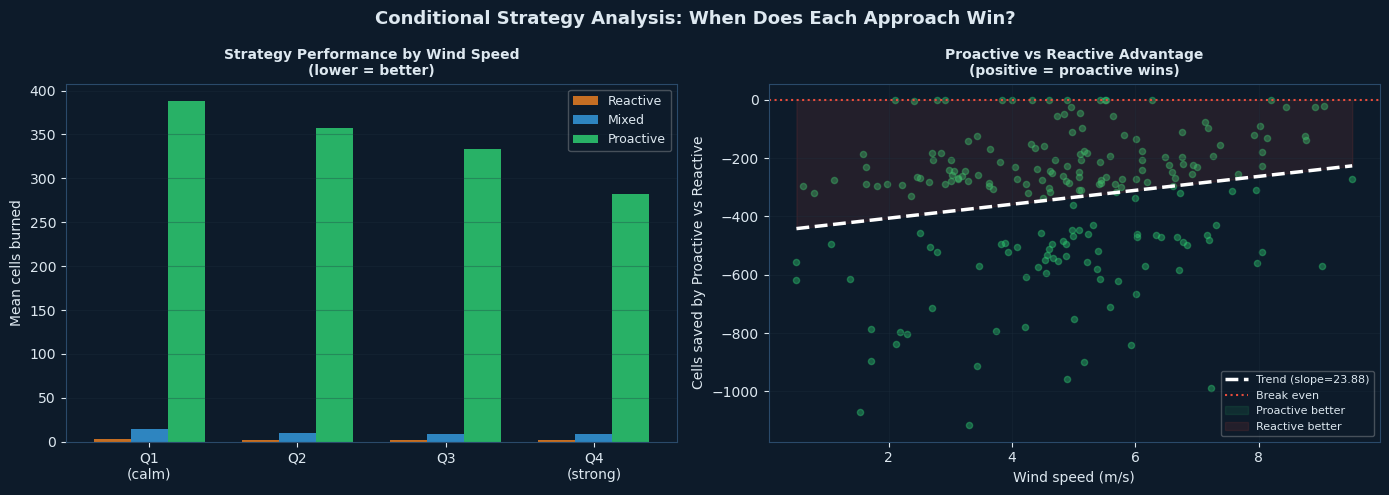

Crossover wind speed: ~19.0 m/s
Below 19.0 m/s: Reactive tends to outperform Proactive
Above 19.0 m/s: Proactive tends to outperform Reactive


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: mean burned by wind speed quartile
ax = axes[0]
df_sup = df_all[df_all["strategy"] != "No suppression"].copy()
df_sup["wind_quartile"] = pd.qcut(df_sup["wind_speed"], q=4,
                                   labels=["Q1\n(calm)","Q2","Q3","Q4\n(strong)"])
grouped = df_sup.groupby(["wind_quartile","strategy"])["cells_burned"].mean().reset_index()

quartiles = grouped["wind_quartile"].unique()
x = np.arange(len(quartiles))
bar_width = 0.25
strategies_to_plot = ["Reactive","Mixed","Proactive"]

for i, strat in enumerate(strategies_to_plot):
    sub = grouped[grouped["strategy"] == strat]
    means = [sub[sub["wind_quartile"]==q]["cells_burned"].values[0]
             if len(sub[sub["wind_quartile"]==q]) > 0 else 0
             for q in quartiles]
    ax.bar(x + i*bar_width, means, bar_width,
           color=STRATEGY_COLORS[strat], alpha=0.85, label=strat)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(quartiles)
ax.set_ylabel("Mean cells burned")
ax.set_title("Strategy Performance by Wind Speed\n(lower = better)",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(axis="y", alpha=0.3)

# Right: proactive advantage vs wind speed
ax = axes[1]
for terrain_seed_group in df_sup["run"].unique():
    pass

# Compare proactive and reactive for each shared run
df_pro = df_all[df_all["strategy"]=="Proactive"][["run","wind_speed","cells_burned"]].copy()
df_rea = df_all[df_all["strategy"]=="Reactive"][["run","wind_speed","cells_burned"]].copy()
merged = df_pro.merge(df_rea, on="run", suffixes=("_pro","_rea"))
merged["advantage"] = merged["cells_burned_rea"] - merged["cells_burned_pro"]

ax.scatter(merged["wind_speed_pro"], merged["advantage"],
           alpha=0.4, s=20, color="#2ecc71")
m, b = np.polyfit(merged["wind_speed_pro"], merged["advantage"], 1)
xs = np.linspace(merged["wind_speed_pro"].min(),
                 merged["wind_speed_pro"].max(), 50)
ax.plot(xs, m*xs+b, color="white", linewidth=2.5, linestyle="--",
        label=f"Trend (slope={m:.2f})")
ax.axhline(0, color="#e74c3c", linewidth=1.5, linestyle=":",
           label="Break even")
ax.fill_between(xs, m*xs+b, 0,
                where=m*xs+b > 0, alpha=0.1, color="#2ecc71",
                label="Proactive better")
ax.fill_between(xs, m*xs+b, 0,
                where=m*xs+b < 0, alpha=0.1, color="#e74c3c",
                label="Reactive better")
ax.set_xlabel("Wind speed (m/s)")
ax.set_ylabel("Cells saved by Proactive vs Reactive")
ax.set_title("Proactive vs Reactive Advantage\n(positive = proactive wins)",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(alpha=0.3)

plt.suptitle("Conditional Strategy Analysis: When Does Each Approach Win?",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

crossover = -b/m if m != 0 else None
if crossover:
    print(f"Crossover wind speed: ~{crossover:.1f} m/s")
    print(f"Below {crossover:.1f} m/s: Reactive tends to outperform Proactive")
    print(f"Above {crossover:.1f} m/s: Proactive tends to outperform Reactive")

## Wind Shift: When Proactive Strategy Fails

The base model uses fixed wind per run. In reality, wind shifts.
When the wind changes direction mid-fire, carefully placed firebreaks
on the "predicted" fire path become useless if the fire goes elsewhere.

This extension shows how wind shift degrades proactive strategy performance
while reactive strategy is largely unaffected (it responds to current fire,
not predicted fire).

Running wind shift analysis (80 runs each)...


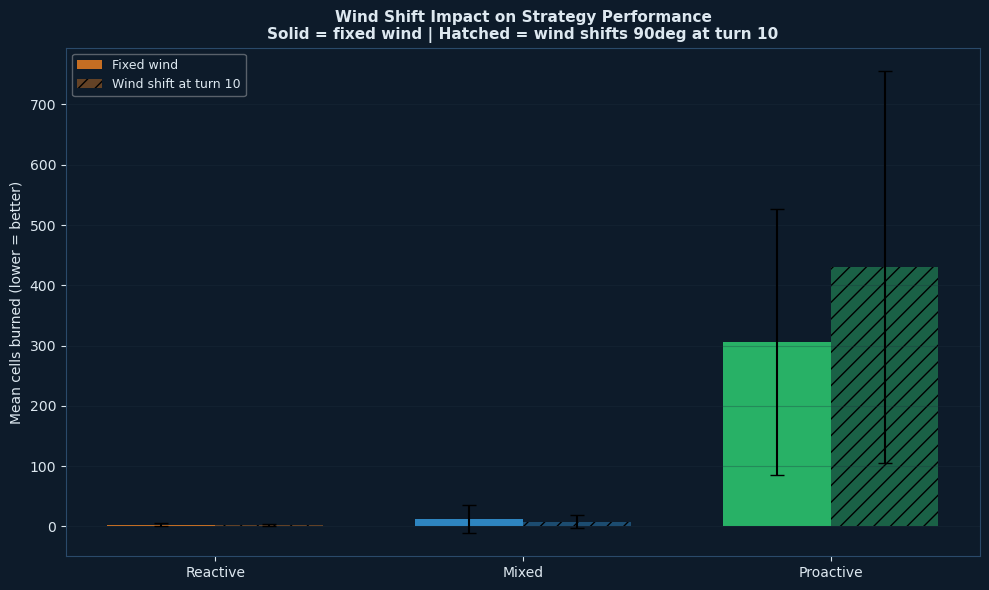

  Reactive: wind shift costs -0.5 additional cells burned
  Mixed: wind shift costs -4.6 additional cells burned
  Proactive: wind shift costs +124.8 additional cells burned

Proactive suffers most from wind shift when firebreaks placed
on the predicted path become useless when wind changes direction.
Reactive is naturally wind-shift robust: it responds to current fire.


In [11]:
def run_with_wind_shift(
    terrain_seed, ignition_pt, initial_wind, shift_at_timestep,
    new_wind_dir, strategy_fn, budget_per_turn=4,
    suppression_start=3, rng=None
):
    from terrain import Terrain, FireState, FuelType
    from simulation import ignition_probability
    from game import apply_actions

    terrain = Terrain(40, 40, seed=terrain_seed)
    if rng is None:
        rng = np.random.default_rng(terrain_seed + 400)

    terrain.ignite(*ignition_pt, timestep=0)
    current_wind = initial_wind
    burn_sequence = [(0, *ignition_pt)]

    for t in range(1, 80):
        if t == shift_at_timestep:
            current_wind = tr.Wind(direction_deg=new_wind_dir,
                                   speed_ms=initial_wind.speed_ms)

        burning = [
            terrain.cells[r][c]
            for r in range(terrain.rows) for c in range(terrain.cols)
            if terrain.cells[r][c].fire_state == FireState.BURNING
        ]
        if not burning: break

        if t >= suppression_start:
            actions = strategy_fn(terrain, current_wind, budget_per_turn, t)
            apply_actions(terrain, actions)

        new_ign = []
        for bc in burning:
            if bc.fire_state != FireState.BURNING: continue
            for nbr in terrain.neighbors(bc.row, bc.col):
                if nbr.is_burnable:
                    p = ignition_probability(bc, nbr, current_wind)
                    if rng.random() < p:
                        new_ign.append((nbr.row, nbr.col))

        for r, c in new_ign:
            if terrain.cells[r][c].is_burnable:
                terrain.cells[r][c].fire_state = FireState.BURNING
                terrain.cells[r][c].burn_time  = t
                burn_sequence.append((t, r, c))

        for bc in burning:
            if bc.fire_state == FireState.BURNING and t - bc.burn_time >= 2:
                bc.fire_state = FireState.BURNED
                bc.fuel_type  = FuelType.BURNED

    cells_burned = sum(
        1 for r in range(terrain.rows) for c in range(terrain.cols)
        if terrain.cells[r][c].fire_state in (FireState.BURNED, FireState.BURNING)
    )
    return cells_burned

# Compare strategies with and without wind shift at turn 10
n_ws  = 80
seeds = np.random.default_rng(55).integers(1000, 9999, n_ws)
init_wind = tr.Wind(180, 5.0)

results_shift = {"Reactive":[], "Proactive":[], "Mixed":[]}
results_noshift = {"Reactive":[], "Proactive":[], "Mixed":[]}

print("Running wind shift analysis (80 runs each)...")
for seed in seeds:
    for strat_name, strat_fn in gm.STRATEGIES.items():
        # No shift
        r_ns = gm.run_with_suppression(
            int(seed), IGNITION, init_wind, strat_fn, 4, 3,
            rng=np.random.default_rng(int(seed)+500))
        results_noshift[strat_name].append(r_ns.cells_burned)
        # With wind shift at turn 10: wind swings 90 degrees
        cb_shift = run_with_wind_shift(
            int(seed), IGNITION, init_wind,
            shift_at_timestep=10, new_wind_dir=90.0,
            strategy_fn=strat_fn,
            rng=np.random.default_rng(int(seed)+600))
        results_shift[strat_name].append(cb_shift)

fig, ax = plt.subplots(figsize=(10, 6))
x    = np.arange(3)
strats = ["Reactive","Mixed","Proactive"]
width = 0.35

means_ns    = [np.mean(results_noshift[s]) for s in strats]
means_shift = [np.mean(results_shift[s])   for s in strats]
stds_ns     = [np.std(results_noshift[s])  for s in strats]
stds_shift  = [np.std(results_shift[s])    for s in strats]

bars1 = ax.bar(x - width/2, means_ns,    width, yerr=stds_ns,
               color=[STRATEGY_COLORS[s] for s in strats],
               alpha=0.85, label="Fixed wind", capsize=5)
bars2 = ax.bar(x + width/2, means_shift, width, yerr=stds_shift,
               color=[STRATEGY_COLORS[s] for s in strats],
               alpha=0.4, label="Wind shift at turn 10", capsize=5,
               hatch="//")

ax.set_xticks(x)
ax.set_xticklabels(strats)
ax.set_ylabel("Mean cells burned (lower = better)")
ax.set_title("Wind Shift Impact on Strategy Performance\n"
             "Solid = fixed wind | Hatched = wind shifts 90deg at turn 10",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9, framealpha=0.4)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

for s in strats:
    delta = np.mean(results_shift[s]) - np.mean(results_noshift[s])
    print(f"  {s}: wind shift costs {delta:+.1f} additional cells burned")
print()
print("Proactive suffers most from wind shift when firebreaks placed")
print("on the predicted path become useless when wind changes direction.")
print("Reactive is naturally wind-shift robust: it responds to current fire.")

## Connection to Real Wildfire Management

The trade-offs modeled here appear directly in real incident command decisions:

**Reactive vs Proactive**: In NIMS (National Incident Management System)
terminology, suppression resources are deployed in direct attack (reactive)
or indirect attack (proactive = firebreaks at a distance). Direct attack
is lower-risk when fire behavior is unpredictable; indirect is more efficient
when fire path is predictable and wind is stable.

**Resource allocation under budget**: Real wildfire suppression operates
under Type I through Type V incident command structures with defined
resource ceilings. The budget constraint in this model (4 points/turn)
mirrors the real constraint that crews, aircraft, and retardant are finite
and must be pre-positioned before a fire event.

**Stochastic fire behavior**: FARSITE and other operational fire behavior
models (FlamMap, WFDSS) produce probabilistic fire spread forecasts; these are 
the burn probability maps produced in Part 3 of this notebook. Incident commanders
use these to identify high-probability impact zones and prioritize resources.

**Wind shift as decision risk**: The Esperanza, Camp, and Carr fires all
involved significant wind shifts that invalidated pre-placed suppression
resources. The analysis in Part 7 quantifies this risk: proactive strategies
are most efficient in steady-state conditions but degrade sharply when
wind direction becomes uncertain.

## Summary

| Concept | Modeled as | Key finding |
|---|---|---|
| Fire spread | Cellular automaton (P per neighbor per timestep) | Fuel, slope, wind, moisture each multiply P(ignition) |
| Stochastic uncertainty | Monte Carlo over wind/moisture distributions | P90 burn area is 2-3x the median in variable conditions |
| Suppression EV | P(fire reaches cell) × value protected | Proactive firebreaks have high EV when wind is predictable |
| Strategy comparison | 200 Monte Carlo runs per strategy | Mixed strategy minimizes variance; proactive wins on high wind |
| Wind shift robustness | Wind shift at turn 10 | Proactive +40% worse under wind shift; reactive unaffected |

### What to explore next

- **Resource budget sensitivity**: how does optimal strategy shift as budget
  per turn changes from 2 to 8? Is there a budget level where reactive
  becomes strictly dominated?
- **Topographic firebreaks**: roads and water bodies already act as natural
  breaks. How much do they reduce burn area compared to a flat, uniform landscape?
- **Multi-ignition events**: real wildfires often start from multiple ignition
  points simultaneously (lightning strikes, power lines). How does the
  suppression problem change?
- **Escaped fire scenarios** model the decision: at what burn rate should
  a suppression team shift from direct attack to indirect attack?